In [20]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from scipy import stats
import statsmodels.api as sm

In [21]:
df = pd.read_csv('/Users/voquangkhai/Downloads/Mental Health and Social Media Balance Project/Mental_Health_and_Social_Media_Balance_Dataset.csv')

In [22]:
ProfileReport(df, title="Mental Health and Social Media Balance Dataset Report").to_file("mental_health_social_media_balance_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 52560.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [24]:
df = df[df['Gender'] != 'Other']

In [25]:
df['User_ID'] = df['User_ID'].astype(str)
df['Sleep_Quality(1-10)'] = df['Sleep_Quality(1-10)'].astype(int)
df['Stress_Level(1-10)'] = df['Stress_Level(1-10)'].astype(int)
df['Days_Without_Social_Media'] = df['Days_Without_Social_Media'].astype(int)
df['Exercise_Frequency(week)'] = df['Exercise_Frequency(week)'].astype(int)
df['Happiness_Index(1-10)'] = df['Happiness_Index(1-10)'].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 477 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    477 non-null    object 
 1   Age                        477 non-null    int64  
 2   Gender                     477 non-null    object 
 3   Daily_Screen_Time(hrs)     477 non-null    float64
 4   Sleep_Quality(1-10)        477 non-null    int64  
 5   Stress_Level(1-10)         477 non-null    int64  
 6   Days_Without_Social_Media  477 non-null    int64  
 7   Exercise_Frequency(week)   477 non-null    int64  
 8   Social_Media_Platform      477 non-null    object 
 9   Happiness_Index(1-10)      477 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 41.0+ KB


In [27]:
df['ScreenTime_Group'] = pd.cut(df['Daily_Screen_Time(hrs)'],
                                bins=[0, 3, 6, 100],
                                labels=['Low (<3h)', 'Medium (3-6h)', 'High (>6h)'])
df['Age_Group'] = pd.cut(df['Age'], bins=[0,25,35,45,200], labels=['18-25','26-35','36-45','46+'])

df['High_Stress'] = (df['Stress_Level(1-10)'] >= 8).astype(int)

In [28]:
print("\nScreenTime groups counts:")
print(df['ScreenTime_Group'].value_counts(dropna=False))
print("\nAge groups counts:")
print(df['Age_Group'].value_counts(dropna=False))
print("\nHigh Stress counts:")
print(df['High_Stress'].value_counts(dropna=False))


ScreenTime groups counts:
ScreenTime_Group
Medium (3-6h)    242
High (>6h)       197
Low (<3h)         38
Name: count, dtype: int64

Age groups counts:
Age_Group
36-45    158
18-25    131
26-35    128
46+       60
Name: count, dtype: int64

High Stress counts:
High_Stress
0    338
1    139
Name: count, dtype: int64


In [29]:
profile_cols = ['Stress_Level(1-10)','Sleep_Quality(1-10)','Happiness_Index(1-10)','Exercise_Frequency(week)','Days_Without_Social_Media']
screen_profile = df.groupby('ScreenTime_Group', observed=False)[profile_cols] \
                    .agg(['count','mean','std']).round(3)

display(screen_profile)


Stress_Level(1-10)               Sleep_Quality(1-10)         \
                              count   mean    std               count   mean   
ScreenTime_Group                                                               
Low (<3h)                        38  4.368  1.101                  38  8.368   
Medium (3-6h)                   242  6.041  1.119                 242  6.872   
High (>6h)                      197  7.761  1.151                 197  5.168   

                        Happiness_Index(1-10)                \
                    std                 count   mean    std   
ScreenTime_Group                                              
Low (<3h)         1.025                    38  9.816  0.609   
Medium (3-6h)     1.190                   242  9.037  1.064   
High (>6h)        1.115                   197  7.239  1.414   

                 Exercise_Frequency(week)                \
                                    count   mean    std   
ScreenTime_Group                                          
Low (<3h)                              38  2.868  1.891   
Medium (3-6h)                         242  2.438  1.448   
High (>6h)                            197  2.381  1.287   

                 Days_Without_Social_Media                
                                     count   mean    std  
ScreenTime_Group                                          
Low (<3h)                               38  3.447  1.856  
Medium (3-6h)                          242  3.140  1.846  
High (>6h)                             197  3.081  1.899

In [30]:
platform_table = df.groupby('Social_Media_Platform')[profile_cols].agg(['count','mean']).round(3)
display(platform_table)

cross = pd.crosstab(df['Social_Media_Platform'], df['High_Stress'])
display(cross)
chi2, p, dof, expected = stats.chi2_contingency(cross.fillna(0))
print(f"Chi-square = {chi2:.3f}")
print(f"p-value    = {p:.4f}")
print(f"dof        = {dof}")


Stress_Level(1-10)        Sleep_Quality(1-10)         \
                                   count   mean               count   mean   
Social_Media_Platform                                                        
Facebook                              80  6.675                  80  6.125   
Instagram                             71  6.930                  71  5.930   
LinkedIn                              83  6.410                  83  6.542   
TikTok                                92  6.565                  92  6.489   
X (Twitter)                           82  6.524                  82  6.280   
YouTube                               69  6.667                  69  6.275   

                      Happiness_Index(1-10)        Exercise_Frequency(week)  \
                                      count   mean                    count   
Social_Media_Platform                                                         
Facebook                                 80  8.338                       80   
Instagram                                71  7.972                       71   
LinkedIn                                 83  8.494                       83   
TikTok                                   92  8.402                       92   
X (Twitter)                              82  8.598                       82   
YouTube                                  69  8.261                       69   

                             Days_Without_Social_Media         
                        mean                     count   mean  
Social_Media_Platform                                          
Facebook               2.250                        80  3.262  
Instagram              2.563                        71  2.634  
LinkedIn               2.434                        83  3.048  
TikTok                 2.696                        92  3.239  
X (Twitter)            2.098                        82  3.268  
YouTube                2.667                        69  3.348

High_Stress,0,1
Social_Media_Platform,,
Facebook,55,25
Instagram,49,22
LinkedIn,65,18
TikTok,65,27
X (Twitter),58,24
YouTube,46,23


Chi-square = 3.113
p-value    = 0.6826
dof        = 5


In [31]:
age_summary = (df.groupby('Age_Group', observed=True)[profile_cols + ['Daily_Screen_Time(hrs)']].agg(['count','mean','std']).round(3))
display(age_summary)

Stress_Level(1-10)               Sleep_Quality(1-10)                \
                       count   mean    std               count   mean    std   
Age_Group                                                                      
18-25                    131  6.504  1.595                 131  6.519  1.595   
26-35                    128  6.781  1.521                 128  6.062  1.505   
36-45                    158  6.544  1.500                 158  6.411  1.515   
46+                       60  6.717  1.606                  60  5.933  1.401   

          Happiness_Index(1-10)               Exercise_Frequency(week)         \
                          count   mean    std                    count   mean   
Age_Group                                                                       
18-25                       131  8.405  1.563                      131  2.298   
26-35                       128  8.188  1.556                      128  2.539   
36-45                       158  8.487  1.431                      158  2.437   
46+                          60  8.267  1.666                       60  2.617   

                 Days_Without_Social_Media                \
             std                     count   mean    std   
Age_Group                                                  
18-25      1.413                       131  3.313  1.961   
26-35      1.368                       128  3.000  1.840   
36-45      1.425                       158  3.025  1.872   
46+        1.585                        60  3.367  1.687   

          Daily_Screen_Time(hrs)                
                           count   mean    std  
Age_Group                                       
18-25                        131  5.374  1.864  
26-35                        128  5.779  1.671  
36-45                        158  5.416  1.667  
46+                           60  5.817  1.783

In [32]:
groups = df.groupby('Age_Group', observed=True)['Stress_Level(1-10)'] \
           .apply(lambda x: x.dropna().values)
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA Stress by Age Group: F={f_stat:.3f}, p={p_val:.4f}")

h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis Stress by Age Group: H={h_stat:.3f}, p={p_kw:.4f}")


ANOVA Stress by Age Group: F=0.915, p=0.4332
Kruskal-Wallis Stress by Age Group: H=2.707, p=0.4391


In [33]:
df['Exercise group'] = pd.cut(df['Exercise_Frequency(week)'], bins=[-0.1,0,2,4,100], labels=['0','1-2','3-4','5+'])
interaction_table = (df.groupby(['Gender','Exercise group'], observed=True)['Stress_Level(1-10)'].agg(['count','mean','std']).round(3).reset_index()
)
display(interaction_table)

,Gender,Exercise group,count,mean,std
0,Female,0,22,6.273,1.667
1,Female,1-2,99,6.869,1.523
2,Female,3-4,86,6.547,1.577
3,Female,5+,22,5.955,1.588
4,Male,0,19,6.211,1.584
5,Male,1-2,113,6.602,1.479
6,Male,3-4,99,6.737,1.575
7,Male,5+,17,6.706,1.359


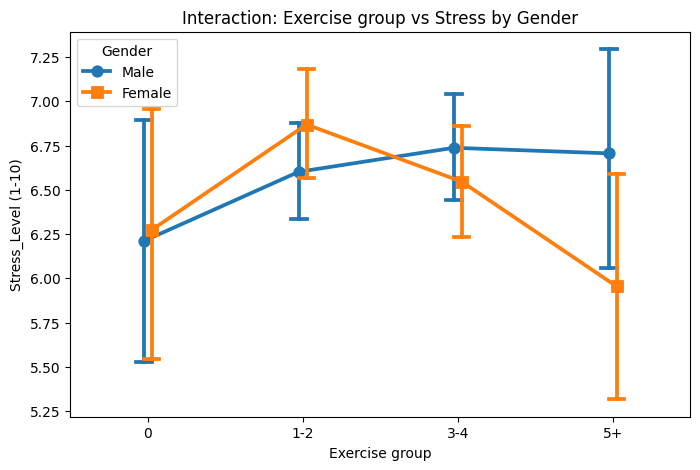

In [34]:
plt.figure(figsize=(8,5))
sns.pointplot(data=df, x='Exercise group', y='Stress_Level(1-10)', hue='Gender', dodge=True, markers=['o','s'], capsize=.1)
plt.title("Interaction: Exercise group vs Stress by Gender")
plt.ylabel("Stress_Level (1-10)")
plt.show()

In [35]:
num_cols = [
    'Age',
    'Daily_Screen_Time(hrs)',
    'Sleep_Quality(1-10)',
    'Stress_Level(1-10)',
    'Days_Without_Social_Media',
    'Exercise_Frequency(week)',
    'Happiness_Index(1-10)'
]

In [36]:
corr_with_stress = df[num_cols].corr()['Stress_Level(1-10)'].drop('Stress_Level(1-10)').sort_values(key=lambda x: x.abs(), ascending=False)
print("\nCorrelation with Stress:")
display(corr_with_stress.round(3))


Correlation with Stress:


Daily_Screen_Time(hrs)       0.741
Happiness_Index(1-10)       -0.741
Sleep_Quality(1-10)         -0.581
Age                          0.028
Exercise_Frequency(week)    -0.013
Days_Without_Social_Media   -0.012
Name: Stress_Level(1-10), dtype: float64

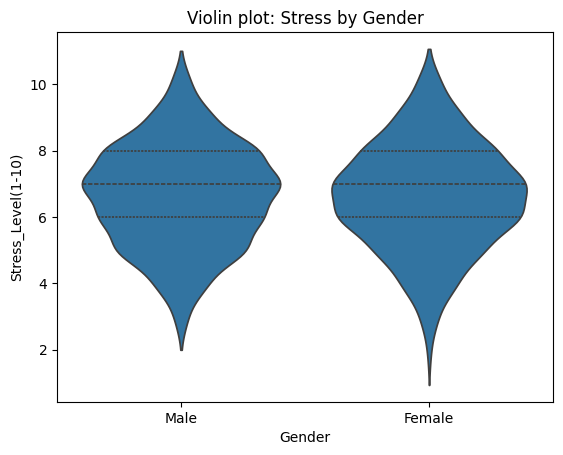

In [37]:
plt.figure()
sns.violinplot(x='Gender', y='Stress_Level(1-10)', data=df, inner='quartile')
plt.title("Violin plot: Stress by Gender")
plt.show()


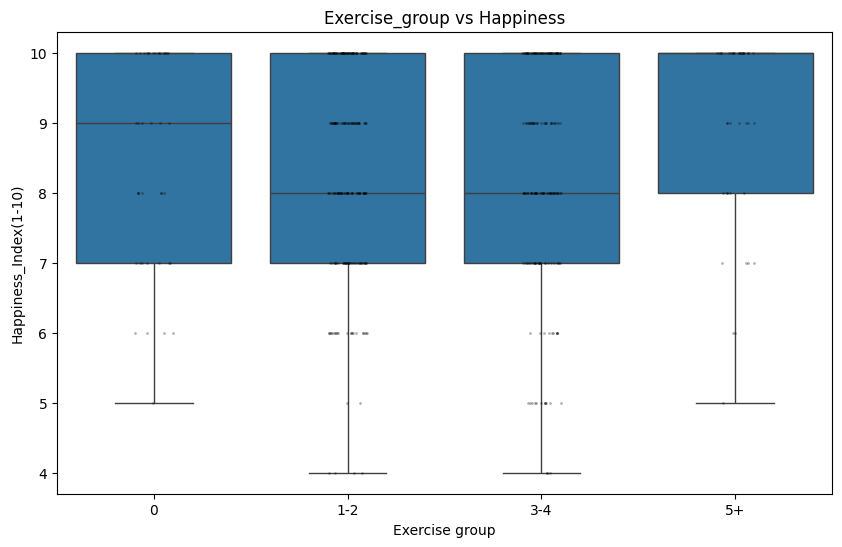

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Exercise group', y='Happiness_Index(1-10)', data=df)
sns.stripplot(x='Exercise group', y='Happiness_Index(1-10)', data=df, color='black', jitter=True, alpha=0.3, size=2)
plt.title("Exercise_group vs Happiness")
plt.show()

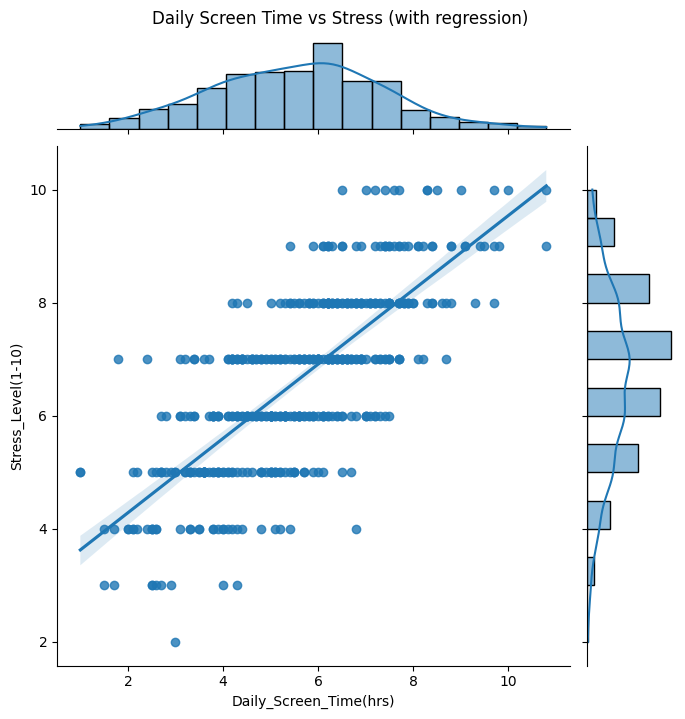

In [41]:
jp = sns.jointplot(data=df, x='Daily_Screen_Time(hrs)', y='Stress_Level(1-10)', kind='reg', height=7)
jp.fig.suptitle("Daily Screen Time vs Stress (with regression)", y=1.02)
plt.show()


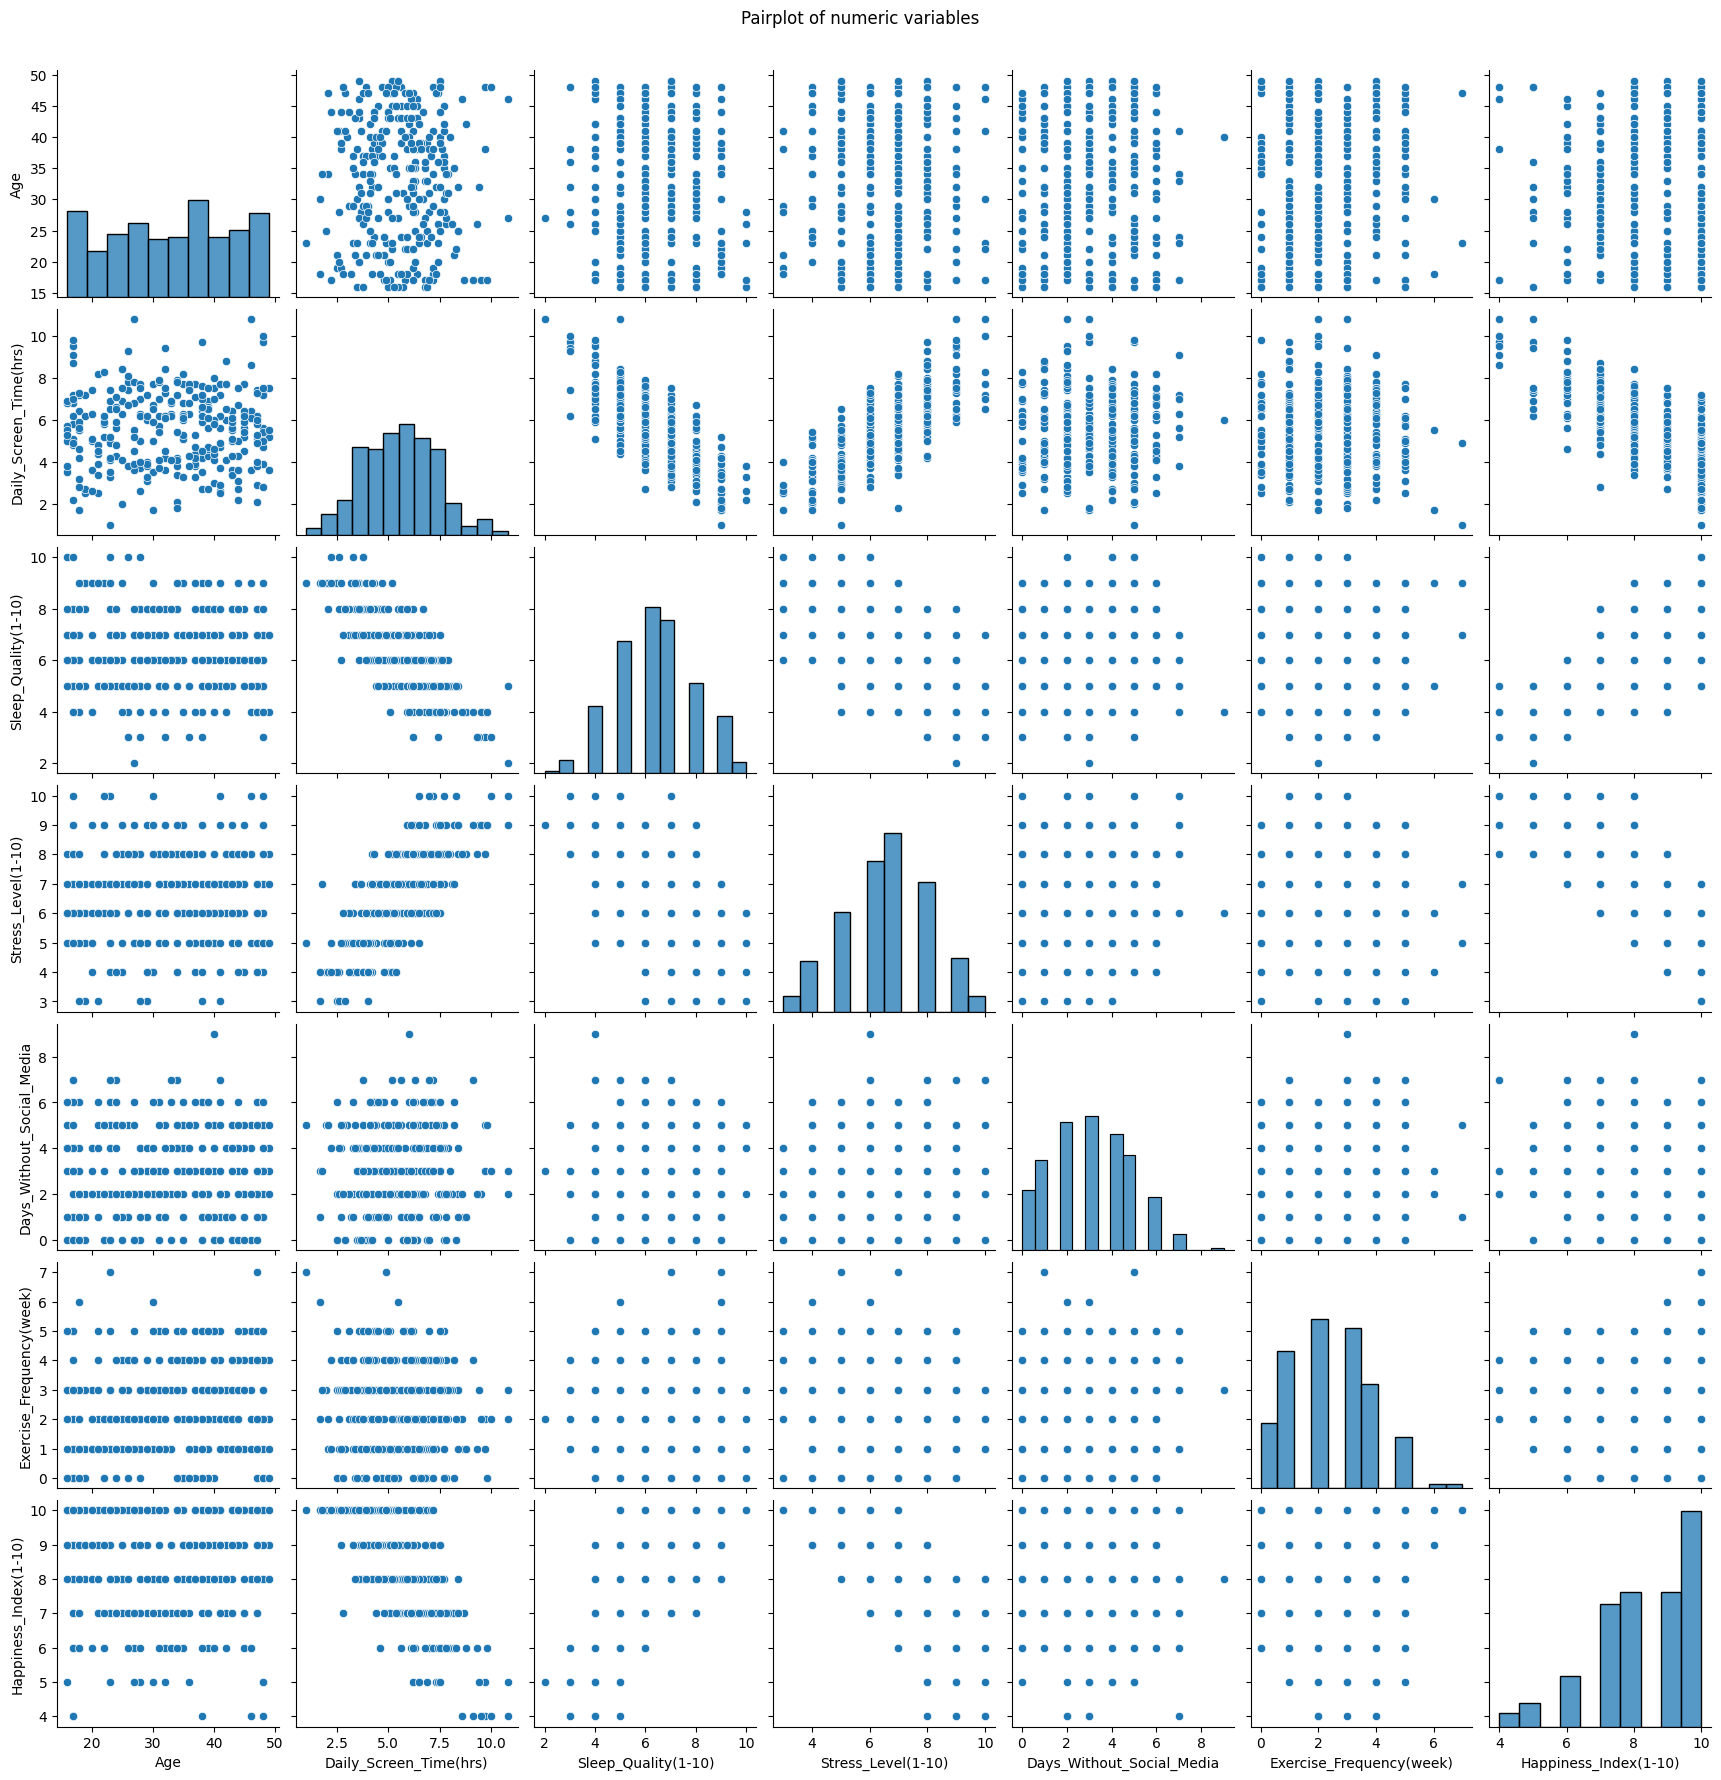

In [43]:
sample_df = df[num_cols].dropna().sample(n=min(300, df.dropna(subset=num_cols).shape[0]), random_state=1)
sns.pairplot(sample_df)
plt.suptitle("Pairplot of numeric variables", y=1.02)
plt.show()

In [44]:
high = df[df['High_Stress']==1]
low = df[df['High_Stress']==0]
print(f"\nHigh stress count: {len(high)} / {len(df)}")
high_profile = high[profile_cols + ['Daily_Screen_Time(hrs)','Exercise_Frequency(week)','Age']].agg(['count','mean','std']).round(3)
low_profile = low[profile_cols + ['Daily_Screen_Time(hrs)','Exercise_Frequency(week)','Age']].agg(['count','mean','std']).round(3)
display(high_profile)
display(low_profile)


High stress count: 139 / 477


,Stress_Level(1-10),Sleep_Quality(1-10),Happiness_Index(1-10),Exercise_Frequency(week),Days_Without_Social_Media,Daily_Screen_Time(hrs),Exercise_Frequency(week),Age
count,139.000,139.000,139.000,139.000,139.000,139.000,139.000,139.000
mean,8.460,5.137,6.806,2.432,3.122,7.174,2.432,33.353
std,0.662,1.235,1.268,1.341,1.980,1.250,1.341,9.706


,Stress_Level(1-10),Sleep_Quality(1-10),Happiness_Index(1-10),Exercise_Frequency(week),Days_Without_Social_Media,Daily_Screen_Time(hrs),Exercise_Frequency(week),Age
count,338.000,338.000,338.000,338.000,338.000,338.000,338.000,338.000
mean,5.861,6.760,8.994,2.456,3.148,4.886,2.456,33.065
std,1.104,1.386,1.122,1.464,1.822,1.458,1.464,10.028


In [46]:
ht = high['Daily_Screen_Time(hrs)'].dropna()
lt = low['Daily_Screen_Time(hrs)'].dropna()
t_res = stats.ttest_ind(ht, lt, equal_var=False)
print("\nT-test ScreenTime: High vs Low stress: t={:.3f}, p={:.4f}".format(t_res.statistic, t_res.pvalue))


T-test ScreenTime: High vs Low stress: t=17.288, p=0.0000
